In [5]:
!nvidia-smi

Tue Apr  7 17:13:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%writefile main.cu

Writing main.cu


In [22]:
!nvcc -std=c++17 -arch=sm_75 main.cu -o app -D TYPE=int

In [23]:
!./app

Type: int
Size: 1000
CPU avg: 0.0046058 ms
GPU total avg: 0.0562624 ms
Kernel: 0.02928 ms
H2D: 0.0128064 ms
D2H: 0.014176 ms
Speedup: 0.0818628
Sum_cpu: 4545
Sum_gpu: 4545
Type: int
Size: 10000
CPU avg: 0.052085 ms
GPU total avg: 0.0506624 ms
Kernel: 0.012128 ms
H2D: 0.026688 ms
D2H: 0.0118464 ms
Speedup: 1.02808
Sum_cpu: 44890
Sum_gpu: 44890
Type: int
Size: 100000
CPU avg: 0.48219 ms
GPU total avg: 0.170054 ms
Kernel: 0.0339776 ms
H2D: 0.12217 ms
D2H: 0.0139072 ms
Speedup: 2.8355
Sum_cpu: 449473
Sum_gpu: 449473
Type: int
Size: 500000
CPU avg: 2.36651 ms
GPU total avg: 0.620448 ms
Kernel: 0.114368 ms
H2D: 0.488038 ms
D2H: 0.0180416 ms
Speedup: 3.81419
Sum_cpu: 2.25346e+06
Sum_gpu: 2.25346e+06
Type: int
Size: 1000000
CPU avg: 5.04773 ms
GPU total avg: 1.09022 ms
Kernel: 0.207744 ms
H2D: 0.859712 ms
D2H: 0.0227648 ms
Speedup: 4.63001
Sum_cpu: 4.50306e+06
Sum_gpu: 4.50306e+06


In [24]:
!nvcc -std=c++17 -arch=sm_75 main.cu -o app -D TYPE=float

In [25]:
!./app

Type: float
Size: 1000
CPU avg: 0.0048898 ms
GPU total avg: 0.0726656 ms
Kernel: 0.02992 ms
H2D: 0.012608 ms
D2H: 0.0301376 ms
Speedup: 0.0672918
Sum_cpu: 4545
Sum_gpu: 4545
Type: float
Size: 10000
CPU avg: 0.0450568 ms
GPU total avg: 0.0587264 ms
Kernel: 0.0128192 ms
H2D: 0.0330048 ms
D2H: 0.0129024 ms
Speedup: 0.767232
Sum_cpu: 44890
Sum_gpu: 44890
Type: float
Size: 100000
CPU avg: 0.466999 ms
GPU total avg: 0.166445 ms
Kernel: 0.034624 ms
H2D: 0.118048 ms
D2H: 0.0137728 ms
Speedup: 2.80573
Sum_cpu: 449473
Sum_gpu: 449473
Type: float
Size: 500000
CPU avg: 2.40614 ms
GPU total avg: 0.626848 ms
Kernel: 0.119072 ms
H2D: 0.490227 ms
D2H: 0.0175488 ms
Speedup: 3.83847
Sum_cpu: 2.25346e+06
Sum_gpu: 2.25346e+06
Type: float
Size: 1000000
CPU avg: 4.79434 ms
GPU total avg: 1.08264 ms
Kernel: 0.22441 ms
H2D: 0.834611 ms
D2H: 0.0236224 ms
Speedup: 4.42837
Sum_cpu: 4.50306e+06
Sum_gpu: 4.50306e+06


In [26]:
!nvcc -std=c++17 -arch=sm_75 main.cu -o app -D TYPE=double

In [27]:
!./app

Type: double
Size: 1000
CPU avg: 0.0050636 ms
GPU total avg: 0.0643712 ms
Kernel: 0.0326592 ms
H2D: 0.016096 ms
D2H: 0.015616 ms
Speedup: 0.0786625
Sum_cpu: 4545
Sum_gpu: 4545
Type: double
Size: 10000
CPU avg: 0.079861 ms
GPU total avg: 0.0704768 ms
Kernel: 0.0157056 ms
H2D: 0.0363072 ms
D2H: 0.018464 ms
Speedup: 1.13315
Sum_cpu: 44890
Sum_gpu: 44890
Type: double
Size: 100000
CPU avg: 0.449628 ms
GPU total avg: 0.300109 ms
Kernel: 0.0382016 ms
H2D: 0.243245 ms
D2H: 0.0186624 ms
Speedup: 1.49822
Sum_cpu: 449473
Sum_gpu: 449473
Type: double
Size: 500000
CPU avg: 2.25613 ms
GPU total avg: 0.994739 ms
Kernel: 0.115674 ms
H2D: 0.86087 ms
D2H: 0.0181952 ms
Speedup: 2.26806
Sum_cpu: 2.25346e+06
Sum_gpu: 2.25346e+06
Type: double
Size: 1000000
CPU avg: 4.57016 ms
GPU total avg: 1.93098 ms
Kernel: 0.219526 ms
H2D: 1.68337 ms
D2H: 0.0280768 ms
Speedup: 2.36676
Sum_cpu: 4.50306e+06
Sum_gpu: 4.50306e+06


In [28]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("results_vec.csv")

print(df)

      type     size  cpu_time_ms  gpu_total_ms  kernel_ms    h2d_ms    d2h_ms  \
0      int     1000     0.004606      0.056262   0.029280  0.012806  0.014176   
1      int    10000     0.052085      0.050662   0.012128  0.026688  0.011846   
2      int   100000     0.482190      0.170054   0.033978  0.122170  0.013907   
3      int   500000     2.366510      0.620448   0.114368  0.488038  0.018042   
4      int  1000000     5.047730      1.090220   0.207744  0.859712  0.022765   
5    float     1000     0.004890      0.072666   0.029920  0.012608  0.030138   
6    float    10000     0.045057      0.058726   0.012819  0.033005  0.012902   
7    float   100000     0.466999      0.166445   0.034624  0.118048  0.013773   
8    float   500000     2.406140      0.626848   0.119072  0.490227  0.017549   
9    float  1000000     4.794340      1.082640   0.224410  0.834611  0.023622   
10  double     1000     0.005064      0.064371   0.032659  0.016096  0.015616   
11  double    10000     0.07

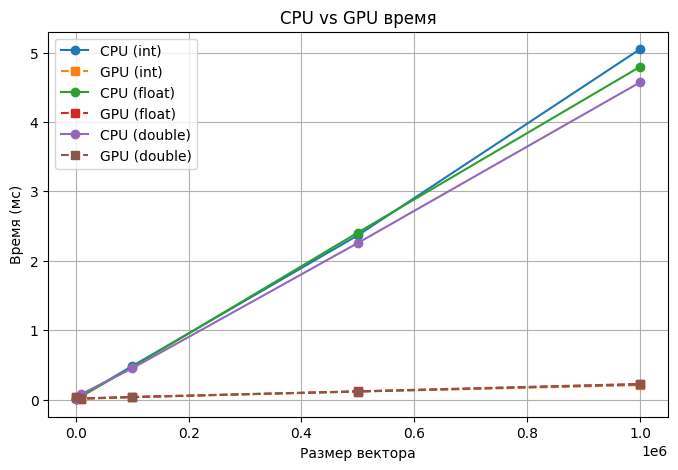

In [29]:
plt.figure(figsize=(8, 5))

for t in df['type'].unique():
    subset = df[df['type'] == t]

    plt.plot(subset['size'], subset['cpu_time_ms'], marker='o', label=f'CPU ({t})')
    plt.plot(subset['size'], subset['kernel_ms'], marker='s', linestyle='--', label=f'GPU ({t})')

plt.xlabel("Размер вектора")
plt.ylabel("Время (мс)")
plt.title("CPU vs GPU время")
plt.legend()
plt.grid()

plt.show()

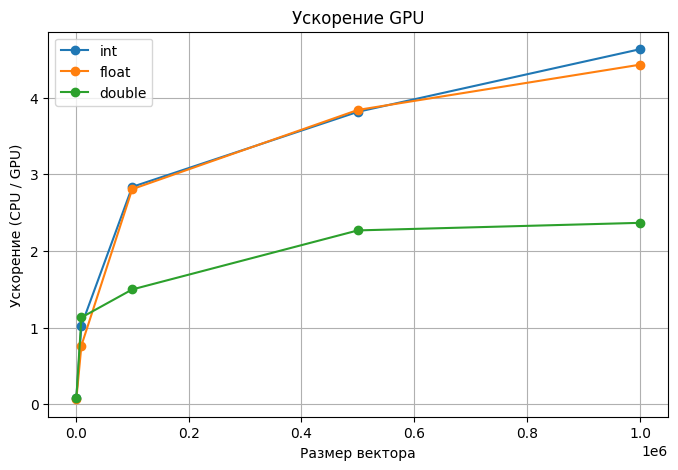

In [30]:
plt.figure(figsize=(8, 5))

for t in df['type'].unique():
    subset = df[df['type'] == t]

    plt.plot(subset['size'], subset['speedup'], marker='o', label=f'{t}')

plt.xlabel("Размер вектора")
plt.ylabel("Ускорение (CPU / GPU)")
plt.title("Ускорение GPU")
plt.legend()
plt.grid()

plt.show()